<a href="https://colab.research.google.com/github/Kartikiscalm/IML-LAB-/blob/labs/B25CM1027_Kartik_A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part A - Linear Regression

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
data = load_diabetes(as_frame=True)
df = data.frame.copy()

## A1. Load, Inspect, and Split

In [61]:
# Q-A1

print("First 5 rows:")
display(df.head())

print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics for target:")
display(df["target"].describe())

X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train_bmi = X_train[["bmi"]]
X_test_bmi = X_test[["bmi"]]

print("\nShapes:")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("X_train_bmi shape:", X_train_bmi.shape)
print("X_test_bmi shape:", X_test_bmi.shape)

First 5 rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Dataset shape:
(442, 11)

Column names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']

Data types:
age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object

Missing values:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Summary statistics for target:


,target
count,442.000000
mean,152.133484
std,77.093005
min,25.000000
25%,87.000000
50%,140.500000
75%,211.500000
max,346.000000



Shapes:
X shape: (442, 10)
y shape: (442,)
X_train shape: (353, 10)
X_test shape: (89, 10)
y_train shape: (353,)
y_test shape: (89,)
X_train_bmi shape: (353, 1)
X_test_bmi shape: (89, 1)


### A1 Interpretation

**Feature matrix (X):** The feature matrix X contains the 10 input features: age, sex, bmi, bp, s1, s2, s3, s4, s5, and s6.

**Target (y):** The target y is the disease-progression value that we want the model to predict.

The features in X are the independent/input variables, while the target y is the dependent/output variable. The test set must remain unseen during model fitting so that it provides an unbiased evaluation of how well the trained model performs on new, unseen data.

## A2. BMI-only Linear Regression

In [62]:
# Q-A2

model_bmi = LinearRegression()
model_bmi.fit(X_train_bmi, y_train)

w = model_bmi.coef_[0]
b = model_bmi.intercept_

print("Coefficient (w):", w)
print("Intercept (b):", b)
print(f"\nFitted equation: y_hat = {w:.4f} * bmi + {b:.4f}")

Coefficient (w): 998.5776891375598
Intercept (b): 152.00335421448167

Fitted equation: y_hat = 998.5777 * bmi + 152.0034


In [63]:
y_pred_bmi = model_bmi.predict(X_test_bmi)

mse_bmi = mean_squared_error(y_test, y_pred_bmi)
rmse_bmi = np.sqrt(mse_bmi)
r2_bmi = r2_score(y_test, y_pred_bmi)

print("Test-set metrics:")
print("MSE:", mse_bmi)
print("RMSE:", rmse_bmi)
print("R2:", r2_bmi)

Test-set metrics:
MSE: 4061.8259284949268
RMSE: 63.73245584860925
R2: 0.23335039815872138


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


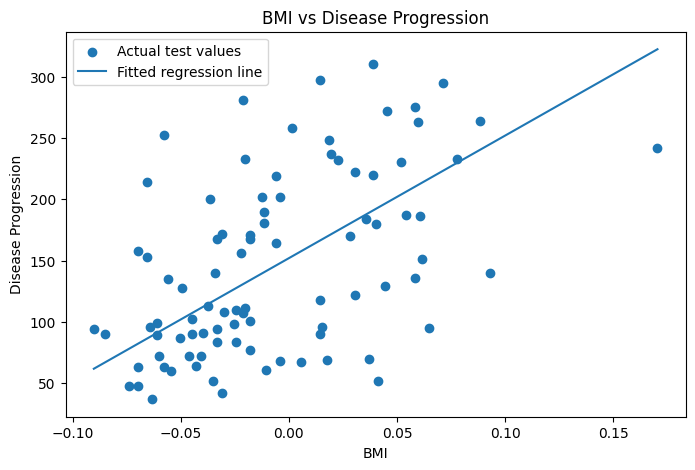

In [64]:
x_sorted = np.sort(X_test_bmi["bmi"].values)
y_sorted = model_bmi.predict(x_sorted.reshape(-1, 1))

plt.figure(figsize=(8, 5))

plt.scatter(
    X_test_bmi["bmi"],
    y_test,
    label="Actual test values"
)

plt.plot(
    x_sorted,
    y_sorted,
    label="Fitted regression line"
)

plt.title("BMI vs Disease Progression")
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.legend()
plt.show()

### A2 Interpretation

The BMI coefficient is positive, indicating that higher values of the scaled BMI feature are associated with higher predicted disease-progression values. The R² value shows how much of the variation in the target is explained by BMI alone. The RMSE represents the typical prediction error on the target scale and is relatively large compared with the mean target value. Overall, BMI alone provides some predictive information but does not explain all the variation in disease progression.

## A3. All-feature Linear Regression

In [65]:
# Q-A3

model_all = LinearRegression()
model_all.fit(X_train, y_train)

y_pred_all = model_all.predict(X_test)

mse_all = mean_squared_error(y_test, y_pred_all)
rmse_all = np.sqrt(mse_all)
r2_all = r2_score(y_test, y_pred_all)

print("All-feature Linear Regression")
print("MSE:", mse_all)
print("RMSE:", rmse_all)
print("R2:", r2_all)

All-feature Linear Regression
MSE: 2900.1936284934814
RMSE: 53.85344583676593
R2: 0.4526027629719195


In [66]:
regression_comparison = pd.DataFrame({
    "Model": ["BMI only", "All 10 features"],
    "MSE": [mse_bmi, mse_all],
    "RMSE": [rmse_bmi, rmse_all],
    "R2": [r2_bmi, r2_all]
})

display(regression_comparison)

,Model,MSE,RMSE,R2
0,BMI only,4061.825928,63.732456,0.233350
1,All 10 features,2900.193628,53.853446,0.452603


In [67]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (353, 10)
X_test shape: (89, 10)
y_train shape: (353,)
y_test shape: (89,)


## A4. Residual and Manual Metric Check

In [68]:
# Q-A4

rmse_change = ((rmse_all - rmse_bmi) / rmse_bmi) * 100

print("RMSE percentage change:", rmse_change)

if rmse_change < 0:
    print("The error improved because RMSE decreased.")
elif rmse_change > 0:
    print("The error worsened because RMSE increased.")
else:
    print("The error remained unchanged.")

RMSE percentage change: -15.50075213688615
The error improved because RMSE decreased.


In [69]:
coefficient_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model_all.coef_,
    "Abs_Coefficient": np.abs(model_all.coef_)
})

coefficient_table = coefficient_table.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

display(coefficient_table.head(5))

,Feature,Coefficient,Abs_Coefficient
4,s1,-931.488846,931.488846
8,s5,736.198859,736.198859
2,bmi,542.428759,542.428759
5,s2,518.062277,518.062277
3,bp,347.703844,347.703844


### A4 Interpretation

The all-feature model improves the prediction error compared with the BMI-only model because its RMSE is lower. The three features with the largest absolute coefficients are identified from the coefficient table above. A large coefficient should not automatically be interpreted as a causal effect or definitive feature importance because coefficients depend on the data, feature scaling, relationships among features, and the model assumptions.

Mean residual: 3.912840375077808
Largest absolute residual: 154.4933747378822


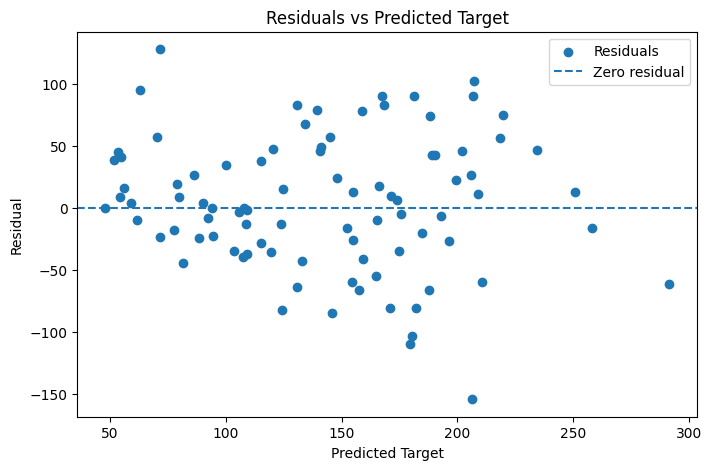

In [70]:
#Q-A5

residuals = y_test - y_pred_all

print("Mean residual:", residuals.mean())
print("Largest absolute residual:", np.max(np.abs(residuals)))

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_all,
    residuals,
    label="Residuals"
)

plt.axhline(
    y=0,
    linestyle="--",
    label="Zero residual"
)

plt.title("Residuals vs Predicted Target")
plt.xlabel("Predicted Target")
plt.ylabel("Residual")
plt.legend()
plt.show()

In [71]:
mse_manual = np.mean(residuals ** 2)
rmse_manual = np.sqrt(mse_manual)

ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

r2_manual = 1 - (ss_res / ss_tot)

print("Manual MSE:", mse_manual)
print("Manual RMSE:", rmse_manual)
print("Manual SS_res:", ss_res)
print("Manual SS_tot:", ss_tot)
print("Manual R2:", r2_manual)

Manual MSE: 2900.1936284934814
Manual RMSE: 53.85344583676593
Manual SS_res: 258117.23293591983
Manual SS_tot: 471535.5056179775
Manual R2: 0.4526027629719195


In [72]:
print("RMSE matches sklearn:", np.allclose(rmse_manual, rmse_all))
print("R2 matches sklearn:", np.allclose(r2_manual, r2_all))

RMSE matches sklearn: True
R2 matches sklearn: True


### A5 Interpretation

The residuals are generally centered around zero, which indicates that the model does not show a strong overall systematic overprediction or underprediction. There may still be some variation in the residuals and a few larger-error cases. The residual plot provides information about prediction errors that cannot be seen from RMSE or R² alone.

## Part A Final Report

In [73]:
display(regression_comparison)

,Model,MSE,RMSE,R2
0,BMI only,4061.825928,63.732456,0.233350
1,All 10 features,2900.193628,53.853446,0.452603


The all-feature linear regression model would be my choice because it performs better than the BMI-only model on the same unseen test data. Its lower RMSE means that, on average, its predictions are closer to the actual disease-progression values. The higher R² also shows that the model explains more of the variation in the target than the BMI-only model. However, the residual plot is useful because it lets us look at the errors directly. It can show whether the errors are roughly centered around zero and whether there are any unusual points or patterns that a single metric might hide. One limitation is that the dataset contains only 442 patients, and the model assumes a linear relationship between the features and the target. Also, a good predictive result does not mean that the features cause changes in disease progression. The model only identifies relationships that help with prediction; establishing causation would require additional evidence and an appropriate study design.

__________________________________________________________

# Part B - Logistic Regression & Binary Classification

In [74]:
import numpy as np
import pandas as pd
rng = np.random.default_rng(2026)
N = 800
temperature_c = rng.normal(72, 10, N).clip(40, 110).round(1)
vibration_mm_s = rng.gamma(shape=2.2, scale=1.4, size=N).clip(0.2, 10).round(2)
pressure_bar = rng.normal(5.5, 0.8, N).clip(3, 8).round(2)
operating_hours = rng.integers(100, 12000, N)
days_since_maintenance = rng.integers(0, 240, N)
load_pct = rng.normal(72, 16, N).clip(20, 100).round(1)
z_true = (-0.8
+ 0.065 * (temperature_c - 72)
+ 0.55 * (vibration_mm_s - 3)
+ 0.18 * (pressure_bar - 5.5)
+ 0.00010 * (operating_hours - 6000)
+ 0.010 * (days_since_maintenance - 100)
+ 0.025 * (load_pct - 72))
p_true = 1 / (1 + np.exp(-z_true))
failure = rng.binomial(1, p_true)
machine_df = pd.DataFrame({
"temperature_c": temperature_c,
"vibration_mm_s": vibration_mm_s,
"pressure_bar": pressure_bar,
"operating_hours": operating_hours,
"days_since_maintenance": days_since_maintenance,
"load_pct": load_pct,
"failure": failure
})
print("Dataset shape:"
, machine_df.shape)
machine_df.head()

Dataset shape: (800, 7)


,temperature_c,vibration_mm_s,pressure_bar,operating_hours,days_since_maintenance,load_pct,failure
0,64.1,4.98,6.15,3558,40,82.6,1
1,74.4,2.33,4.96,1057,179,52.6,0
2,53.0,4.10,5.15,9375,208,74.5,1
3,86.0,1.56,5.33,6638,85,76.5,0
4,78.4,3.75,6.77,2641,3,56.1,0


## B1. Data Exploration

In [75]:
print("First 5 rows:")
display(machine_df.head())

print("Dataset shape:")
print(machine_df.shape)

print("\nData types:")
print(machine_df.dtypes)

print("\nSummary statistics:")
display(machine_df.describe())

print("\nMissing values:")
print(machine_df.isnull().sum())

First 5 rows:


,temperature_c,vibration_mm_s,pressure_bar,operating_hours,days_since_maintenance,load_pct,failure
0,64.1,4.98,6.15,3558,40,82.6,1
1,74.4,2.33,4.96,1057,179,52.6,0
2,53.0,4.10,5.15,9375,208,74.5,1
3,86.0,1.56,5.33,6638,85,76.5,0
4,78.4,3.75,6.77,2641,3,56.1,0


Dataset shape:
(800, 7)

Data types:
temperature_c             float64
vibration_mm_s            float64
pressure_bar              float64
operating_hours             int64
days_since_maintenance      int64
load_pct                  float64
failure                     int64
dtype: object

Summary statistics:


,temperature_c,vibration_mm_s,pressure_bar,operating_hours,days_since_maintenance,load_pct,failure
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,72.405375,2.959050,5.477125,6074.791250,120.411250,72.309250,0.395000
std,10.257544,1.942038,0.814423,3478.100465,69.489878,15.244607,0.489157
min,40.000000,0.200000,3.000000,117.000000,0.000000,23.800000,0.000000
25%,65.400000,1.507500,4.890000,2996.750000,58.000000,62.200000,0.000000
50%,72.600000,2.530000,5.525000,6051.500000,127.000000,72.950000,0.000000
75%,79.200000,3.970000,6.060000,9023.250000,178.000000,82.900000,1.000000
max,104.400000,10.000000,7.680000,11999.000000,239.000000,100.000000,1.000000



Missing values:
temperature_c             0
vibration_mm_s            0
pressure_bar              0
operating_hours           0
days_since_maintenance    0
load_pct                  0
failure                   0
dtype: int64


In [76]:
class_counts = machine_df["failure"].value_counts().sort_index()
class_percentages = machine_df["failure"].value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

display(class_summary)

,Count,Percentage
failure,,
0,484,60.5
1,316,39.5


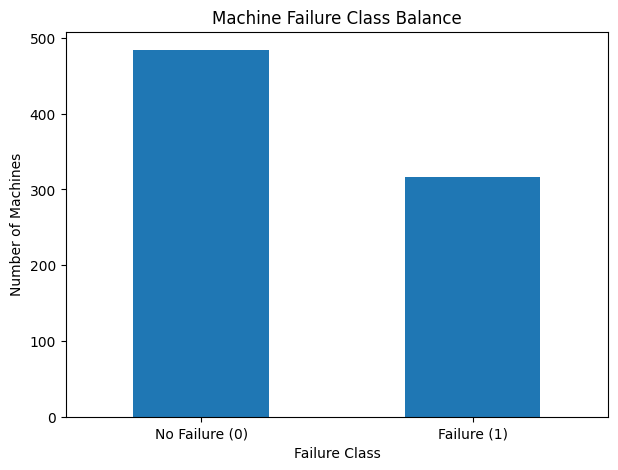

In [77]:
plt.figure(figsize=(7, 5))

class_counts.plot(kind="bar")

plt.title("Machine Failure Class Balance")
plt.xlabel("Failure Class")
plt.ylabel("Number of Machines")
plt.xticks([0, 1], ["No Failure (0)", "Failure (1)"], rotation=0)
plt.show()

<Figure size 800x500 with 0 Axes>

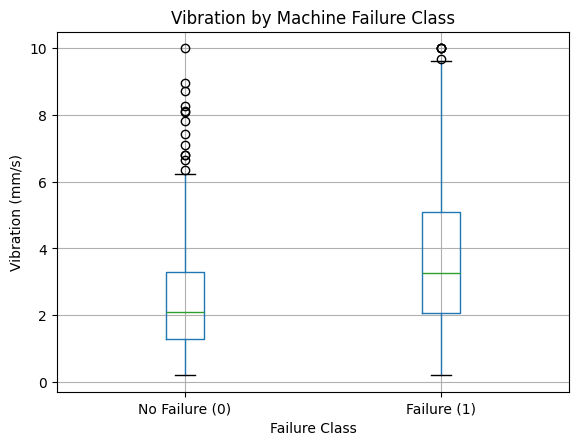

In [78]:
plt.figure(figsize=(8, 5))

machine_df.boxplot(
    column="vibration_mm_s",
    by="failure"
)

plt.title("Vibration by Machine Failure Class")
plt.suptitle("")
plt.xlabel("Failure Class")
plt.ylabel("Vibration (mm/s)")
plt.xticks([1, 2], ["No Failure (0)", "Failure (1)"])
plt.show()

### B1 Interpretation

The dataset contains both machines that fail within the next 7 days and machines that do not fail. The class distribution shows whether the positive failure class is balanced with the non-failure class or occurs less frequently. The feature comparison also gives an initial view of how machine conditions differ between the two classes. Accuracy alone may be misleading when the classes are imbalanced because a model could achieve high accuracy by mainly predicting the majority class while still performing poorly on actual machine failures.

## B2. Split, Scale, and Train

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

features = [
    "temperature_c",
    "vibration_mm_s",
    "pressure_bar",
    "operating_hours",
    "days_since_maintenance",
    "load_pct"
]

X = machine_df[features]
y = machine_df["failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (600, 6)
X_test shape: (200, 6)
y_train shape: (600,)
y_test shape: (200,)


In [80]:
print("Training class percentages:")
print(y_train.value_counts(normalize=True).sort_index() * 100)

print("\nTest class percentages:")
print(y_test.value_counts(normalize=True).sort_index() * 100)

Training class percentages:
failure
0    60.5
1    39.5
Name: proportion, dtype: float64

Test class percentages:
failure
0    60.5
1    39.5
Name: proportion, dtype: float64


In [81]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [82]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### B2 Interpretation

The dataset was split into training and test sets using a 75/25 ratio while preserving the class distribution with stratified splitting. StandardScaler was fitted only on the training data and then used to transform both datasets. Scaling is useful for logistic regression because the features have very different numerical ranges. Using the test data to fit the scaler could cause data leakage and give an overly optimistic evaluation of the model.

## B3. Probability and Baseline Evaluation

In [83]:
y_pred = logistic_model.predict(X_test_scaled)
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("First 10 predicted labels:")
print(y_pred[:10])

print("\nFirst 10 predicted failure probabilities:")
print(y_prob[:10])

First 10 predicted labels:
[0 0 0 0 0 1 0 1 0 0]

First 10 predicted failure probabilities:
[0.25271304 0.30184658 0.44424435 0.39648446 0.11004036 0.8731072
 0.12646108 0.62863083 0.09658204 0.31481114]


In [84]:
first_test_scaled = X_test_scaled[0]

z_manual = (
    logistic_model.intercept_[0]
    + np.dot(logistic_model.coef_[0], first_test_scaled)
)

prob_manual = 1 / (1 + np.exp(-z_manual))

prob_model = y_prob[0]

print("Manual probability:", prob_manual)
print("Model probability:", prob_model)
print("Probabilities match:", np.allclose(prob_manual, prob_model))

Manual probability: 0.25271304251116067
Model probability: 0.25271304251116067
Probabilities match: True


In [85]:
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(y_test, y_pred)

majority_class = y_train.mode()[0]
baseline_predictions = np.full(len(y_test), majority_class)

baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print("Logistic Regression Accuracy:", logistic_accuracy)
print("Majority-Class Baseline Accuracy:", baseline_accuracy)

if logistic_accuracy > baseline_accuracy:
    print("Logistic Regression improves over the majority-class baseline.")
else:
    print("Logistic Regression does not improve over the majority-class baseline.")

Logistic Regression Accuracy: 0.705
Majority-Class Baseline Accuracy: 0.605
Logistic Regression improves over the majority-class baseline.


### B3 Interpretation

The logistic regression model produces both class predictions and probabilities for machine failure. The manually calculated probability for the first test example matches the probability returned by `predict_proba()`, confirming the logistic regression calculation. The majority-class baseline provides a simple reference point for accuracy. The logistic regression model should be compared against this baseline because accuracy by itself does not show whether the model is successfully identifying the machines that actually fail.

## B4. Coefficient Analysis

In [86]:
coefficient_table = pd.DataFrame({
    "Feature": features,
    "Coefficient": logistic_model.coef_[0],
    "Abs_Coefficient": np.abs(logistic_model.coef_[0])
})

coefficient_table = coefficient_table.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

display(coefficient_table)

,Feature,Coefficient,Abs_Coefficient
1,vibration_mm_s,0.820191,0.820191
0,temperature_c,0.807966,0.807966
4,days_since_maintenance,0.555360,0.555360
5,load_pct,0.426859,0.426859
3,operating_hours,0.308143,0.308143
2,pressure_bar,0.056156,0.056156


In [87]:
top_3 = coefficient_table.head(3)

print("Three features with the largest absolute coefficients:")
display(top_3)

Three features with the largest absolute coefficients:


,Feature,Coefficient,Abs_Coefficient
1,vibration_mm_s,0.820191,0.820191
0,temperature_c,0.807966,0.807966
4,days_since_maintenance,0.555360,0.555360


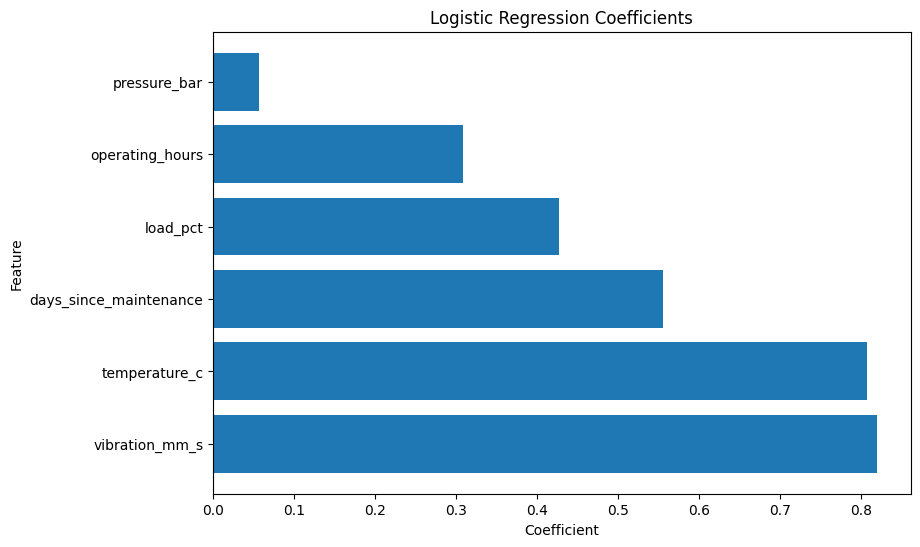

In [88]:
plt.figure(figsize=(9, 6))

plt.barh(
    coefficient_table["Feature"],
    coefficient_table["Coefficient"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

### B4 Interpretation

The three features with the largest absolute coefficients are the three features shown at the top of the coefficient table. A positive coefficient means that, while the other features are held constant, increasing that standardized feature tends to increase the predicted probability of failure. A negative coefficient means that increasing the feature tends to decrease the predicted probability of failure.

Because the features were standardized before training, the coefficient magnitudes can be compared more meaningfully across features. However, a large coefficient should not automatically be treated as proof that the feature causes machine failure or as a perfect measure of feature importance. The coefficients describe relationships learned by this particular logistic regression model and dataset.

## Part B Final Report

The logistic regression model performed better than the majority-class baseline, showing that the model is able to use the machine features to make useful failure predictions rather than simply predicting the most common class. For this problem, I would care most about false negatives because they represent machines that are predicted not to fail even though they actually fail. Missing these machines could lead to unexpected breakdowns and maintenance problems. I would use the standard 0.5 probability threshold as a starting point because it provides a simple balance between the two classes. However, if missing a failure is more costly, the threshold could be lowered so that more possible failures are detected. From the coefficient analysis, the features with the largest absolute coefficients have the strongest influence on the model's predictions. One limitation is that the model is based on a synthetic dataset, so its performance may not represent real industrial machines.